## Objective

This notebook builds a classification model to predict whether a project term will be **delayed** relative to its original baseline schedule, using features engineered from the normalized project tables (contribution, time logs, legal activity, PMO activity, and finance activity).

### Granularity
Each row represents one **Job Code + Term** combination — the same unit used in the Master Baseline and Plan History tables. Project-level tables without a Term column (Contribution Partner, Time Contribution, Legal Activity, PMO Activity, Finance Activity) are aggregated to the Job Code level and applied across all terms of that project.

### Target Variable
- `delay_days` = (final revised plan date) − (original baseline date), in days
- `delayed` = 1 if `delay_days > 0`, else 0

The final revised plan date is taken as the latest revision recorded in Plan History for each Job Code + Term.

### Data Leakage Note
`num_revisions` is partly a *symptom* of delay rather than a clean upstream predictor — projects that are already running late tend to accumulate more revisions. This model is therefore framed as identifying **correlates of delay** (useful for understanding which project characteristics are associated with schedule slippage) rather than a real-time early-warning system. A future extension could restrict features to only what's known within the first revision or first 30 days of a term, to build a genuine early-prediction model without this leakage risk.

### Synthetic Data Note
Several of the underlying tables (contribution, time logs, legal activity, plan history) were generated as mock data rather than sourced directly from a live system, since this data wasn't available in the original raw dataset due to confidentiality. The modeling pipeline below — feature engineering, train/test evaluation, and interpretability — is built to demonstrate the same methodology that would be applied to real project data, and a quick signal check (correlation between `num_revisions` and `delay_days` = 0.35) confirmed the synthetic data carries genuine, non-random structure worth modeling.

## Imports & Load

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

In [24]:
contribution = pd.read_csv('data/processed/contribution_partner.csv')
time_contrib = pd.read_csv('data/processed/time_contribution.csv')
legal = pd.read_csv('data/processed/legal_activity.csv')
pmo = pd.read_csv('data/processed/pmo_activity.csv')
baseline = pd.read_csv('data/processed/master_baseline.csv')
plan_history = pd.read_csv('data/processed/plan_history.csv')
finance = pd.read_csv('data/processed/finance_activity.csv')

for d in [contribution, time_contrib, legal, pmo, baseline, plan_history, finance]:
    d['Job Code'] = d['Job Code'].str.strip()

## Build the Target Variable

In [25]:
# Get the final (latest) plan date per Job Code + Term
final_plans = (plan_history
    .sort_values('Revision')
    .groupby(['Job Code', 'Term'])
    .last()
    .reset_index()[['Job Code', 'Term', 'Plan Date']])

# Merge with baseline
target_df = baseline.merge(final_plans, on=['Job Code', 'Term'], how='inner')

target_df['Baseline Date'] = pd.to_datetime(target_df['Baseline Date'], errors='coerce')
target_df['Plan Date'] = pd.to_datetime(target_df['Plan Date'], errors='coerce')

# Check for parsing failures / missing dates BEFORE computing delay
print("NaNs in Baseline Date:", target_df['Baseline Date'].isna().sum())
print("NaNs in Plan Date:", target_df['Plan Date'].isna().sum())

target_df['delay_days'] = (target_df['Plan Date'] - target_df['Baseline Date']).dt.days

print("NaNs in delay_days:", target_df['delay_days'].isna().sum())
print("Rows before dropping NaNs:", len(target_df))

# Inspect the broken rows before dropping them
display(target_df[target_df['delay_days'].isna()].head(10))

# Drop rows where delay_days couldn't be computed
target_df = target_df.dropna(subset=['delay_days']).copy()
target_df['delayed'] = (target_df['delay_days'] > 0).astype(int)

print("Rows after dropping NaNs:", len(target_df))
print(target_df['delay_days'].describe())
print(target_df['delayed'].value_counts())

NaNs in Baseline Date: 150
NaNs in Plan Date: 150
NaNs in delay_days: 150
Rows before dropping NaNs: 5679


,Job Code,Term,Baseline Date,Plan Date,delay_days
27,BCDR017,1.0,NaT,NaT,NaN
59,BCDR030,1.0,NaT,NaT,NaN
60,BCDR030,2.0,NaT,NaT,NaN
61,BCDR030,3.0,NaT,NaT,NaN
62,BCDR030,4.0,NaT,NaT,NaN
117,BPIR006,1.0,NaT,NaT,NaN
118,BPIR007,1.0,NaT,NaT,NaN
145,BSOP003,1.0,NaT,NaT,NaN
165,BSOP011,1.0,NaT,NaT,NaN
184,BSOP019,1.0,NaT,NaT,NaN


Rows after dropping NaNs: 5529
count    5529.000000
mean        8.944113
std        10.875194
min       -20.000000
25%         1.000000
50%         8.000000
75%        16.000000
max        51.000000
Name: delay_days, dtype: float64
delayed
1    4244
0    1285
Name: count, dtype: int64


In [26]:
num_revisions = plan_history.groupby(['Job Code', 'Term']).size().reset_index(name='num_revisions')
check_df = target_df.merge(num_revisions, on=['Job Code', 'Term'])
print(check_df[['num_revisions', 'delay_days']].corr())

               num_revisions  delay_days
num_revisions       1.000000    0.354794
delay_days          0.354794    1.000000


## Aggregate project-level features

In [27]:
team_features = contribution.groupby('Job Code').agg(
    team_size=('Employee', 'nunique'),
    total_contribution_score=('Score Contribution (%)', 'sum'),
    avg_contribution_score=('Score Contribution (%)', 'mean')
).reset_index()

has_co_lead = contribution.groupby('Job Code')['Position'].apply(
    lambda x: int(x.isin(['Co-PD', 'Co-PM']).any())
).reset_index(name='has_co_lead')

team_features = team_features.merge(has_co_lead, on='Job Code')

time_features = time_contrib.groupby('Job Code').agg(
    total_time_hours=('Time Contribution (hours)', 'sum')
).reset_index()

legal_features = legal.groupby('Job Code').size().reset_index(name='num_legal_activities')
pmo_features = pmo.groupby('Job Code').size().reset_index(name='num_pmo_activities')
finance_features = finance.groupby('Job Code').size().reset_index(name='num_finance_activities')

In [28]:
# Merge everything

model_df = target_df.merge(num_revisions, on=['Job Code', 'Term'], how='left')
model_df = model_df.merge(team_features, on='Job Code', how='left')
model_df = model_df.merge(time_features, on='Job Code', how='left')
model_df = model_df.merge(legal_features, on='Job Code', how='left')
model_df = model_df.merge(pmo_features, on='Job Code', how='left')
model_df = model_df.merge(finance_features, on='Job Code', how='left')

model_df = model_df.fillna(0)
print(model_df.shape)
model_df.head()

(5529, 15)


,Job Code,Term,Baseline Date,Plan Date,delay_days,delayed,num_revisions,team_size,total_contribution_score,avg_contribution_score,has_co_lead,total_time_hours,num_legal_activities,num_pmo_activities,num_finance_activities
0,BBN01-25-11-01,1.0,2026-01-09,2026-01-02,-7.0,0,1,3,200,50.0,1,80,0.0,0.0,9
1,BBN01-25-11-01,2.0,2026-01-28,2026-01-25,-3.0,0,3,3,200,50.0,1,80,0.0,0.0,9
2,BBN01-25-11-01,3.0,2026-03-10,2026-03-24,14.0,1,1,3,200,50.0,1,80,0.0,0.0,9
3,BCA01-25-09-01,1.0,2025-11-14,2025-11-25,11.0,1,1,2,200,100.0,0,80,3.0,8.0,14
4,BCA01-25-09-01,2.0,2025-12-03,2025-11-14,-19.0,0,4,2,200,100.0,0,80,3.0,8.0,14


## Correlation of all features against the target

In [29]:
feature_cols = ['num_revisions', 'team_size', 'total_contribution_score', 
                'avg_contribution_score', 'has_co_lead', 'total_time_hours',
                'num_legal_activities', 'num_pmo_activities', 'num_finance_activities']

correlations = model_df[feature_cols + ['delay_days']].corr()['delay_days'].sort_values(ascending=False)
print(correlations)

delay_days                  1.000000
num_revisions               0.354794
has_co_lead                 0.025195
team_size                   0.016282
num_finance_activities     -0.002011
num_pmo_activities         -0.006313
num_legal_activities       -0.009444
avg_contribution_score     -0.020712
total_contribution_score         NaN
total_time_hours                 NaN
Name: delay_days, dtype: float64


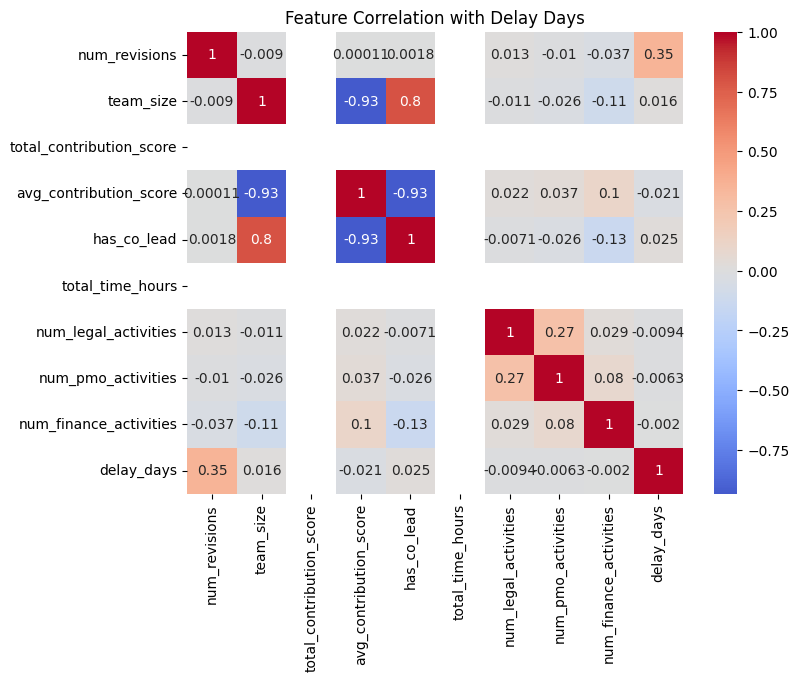

In [30]:
plt.figure(figsize=(8,6))
sns.heatmap(model_df[feature_cols + ['delay_days']].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlation with Delay Days')
plt.show()

`total_contribution_score` and `total_time_hours` came back as NaN in the correlation, which happens when a column has zero variance (every value is identical). Hence, I drop both columns as they add nothing to the model.

In [31]:
print(model_df['total_contribution_score'].nunique())
print(model_df['total_contribution_score'].value_counts().head())
print(model_df['total_time_hours'].nunique())
print(model_df['total_time_hours'].value_counts().head())

1
total_contribution_score
200    5529
Name: count, dtype: int64
1
total_time_hours
80    5529
Name: count, dtype: int64


In [32]:
model_df = model_df.drop(columns=['total_contribution_score', 'total_time_hours'])

## Train/test Split

In [33]:
feature_cols = ['num_revisions', 'avg_contribution_score', 'has_co_lead',
                'num_legal_activities', 'num_pmo_activities', 'num_finance_activities']

X = model_df[feature_cols]
y = model_df['delayed']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Train class balance:\n", y_train.value_counts(normalize=True))
print("Test class balance:\n", y_test.value_counts(normalize=True))

Train shape: (4423, 6)
Test shape: (1106, 6)
Train class balance:
 delayed
1    0.767579
0    0.232421
Name: proportion, dtype: float64
Test class balance:
 delayed
1    0.767631
0    0.232369
Name: proportion, dtype: float64


# Modeling

## 1. Baseline logistic regression

In [34]:
# Scale features (logistic regression benefits from this)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# class_weight='balanced' accounts for the 77/23 imbalance
log_reg = LogisticRegression(class_weight='balanced', random_state=42)
log_reg.fit(X_train_scaled, y_train)

y_pred = log_reg.predict(X_test_scaled)
y_proba = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Coefficients — which features push toward "delayed"?
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': log_reg.coef_[0]
}).sort_values('coefficient', ascending=False)
print(coef_df)

              precision    recall  f1-score   support

           0       0.30      0.65      0.41       257
           1       0.84      0.55      0.66       849

    accuracy                           0.57      1106
   macro avg       0.57      0.60      0.54      1106
weighted avg       0.71      0.57      0.60      1106

ROC-AUC: 0.630075208645557
Confusion Matrix:
 [[167  90]
 [386 463]]
                  feature  coefficient
0           num_revisions     0.400605
5  num_finance_activities     0.011210
2             has_co_lead    -0.014942
4      num_pmo_activities    -0.016491
3    num_legal_activities    -0.036144
1  avg_contribution_score    -0.107384


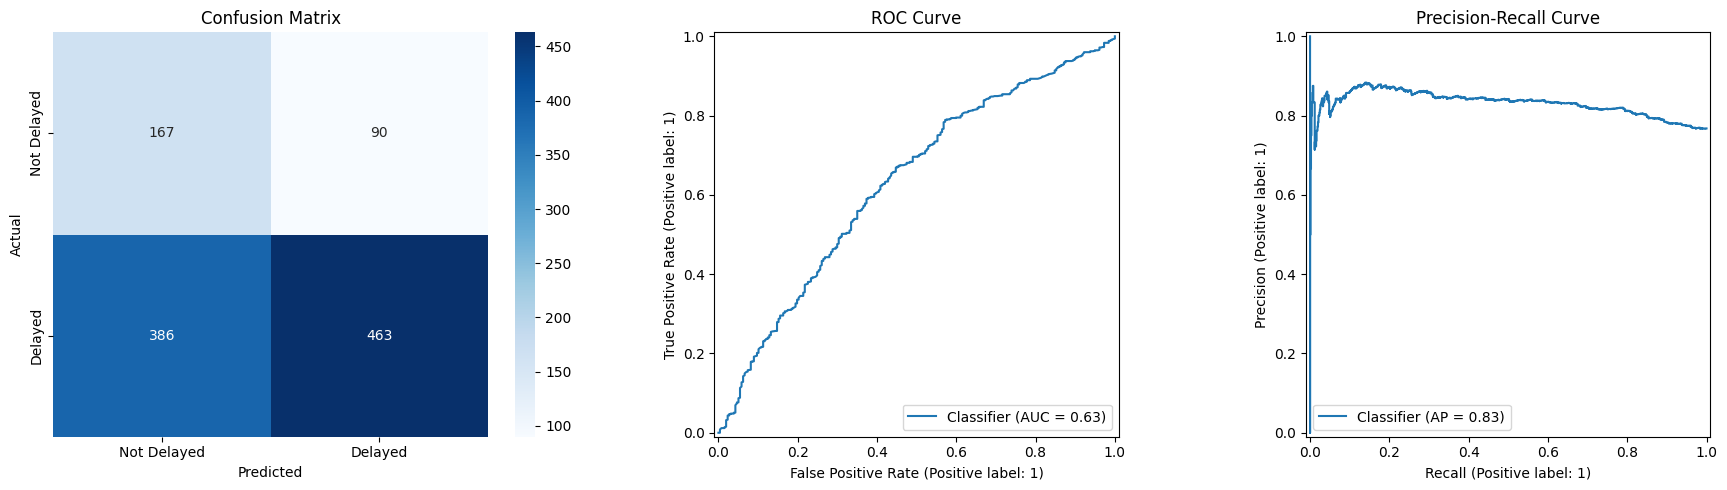

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Delayed', 'Delayed'], 
            yticklabels=['Not Delayed', 'Delayed'], ax=axes[0])
axes[0].set_title('Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# ROC curve
RocCurveDisplay.from_predictions(y_test, y_proba, ax=axes[1])
axes[1].set_title('ROC Curve')

# Precision-Recall curve
PrecisionRecallDisplay.from_predictions(y_test, y_proba, ax=axes[2])
axes[2].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.show()

## 2. XGBoost Model

In [36]:
from xgboost import XGBClassifier

# scale_pos_weight handles the 77/23 imbalance the XGBoost way
# (ratio of negative to positive class in training data)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train, y_train)  # no scaling needed for tree-based models

y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb))

              precision    recall  f1-score   support

           0       0.31      0.56      0.40       257
           1       0.82      0.62      0.71       849

    accuracy                           0.61      1106
   macro avg       0.57      0.59      0.56      1106
weighted avg       0.71      0.61      0.64      1106

ROC-AUC: 0.6082321614350599


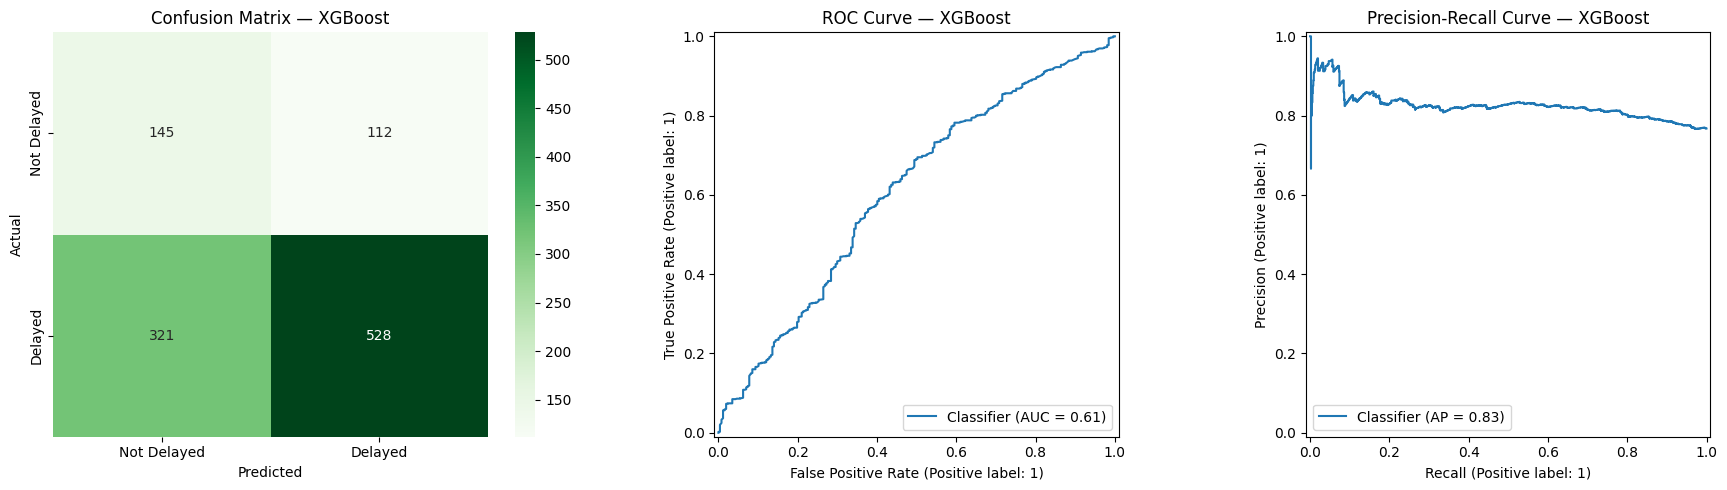

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm_xgb = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Not Delayed', 'Delayed'],
            yticklabels=['Not Delayed', 'Delayed'], ax=axes[0])
axes[0].set_title('Confusion Matrix — XGBoost')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

RocCurveDisplay.from_predictions(y_test, y_proba_xgb, ax=axes[1])
axes[1].set_title('ROC Curve — XGBoost')

PrecisionRecallDisplay.from_predictions(y_test, y_proba_xgb, ax=axes[2])
axes[2].set_title('Precision-Recall Curve — XGBoost')

plt.tight_layout()
plt.show()

## Feature Importance

                  feature  importance
0           num_revisions    0.440770
3    num_legal_activities    0.190669
1  avg_contribution_score    0.132395
5  num_finance_activities    0.120029
4      num_pmo_activities    0.116137
2             has_co_lead    0.000000


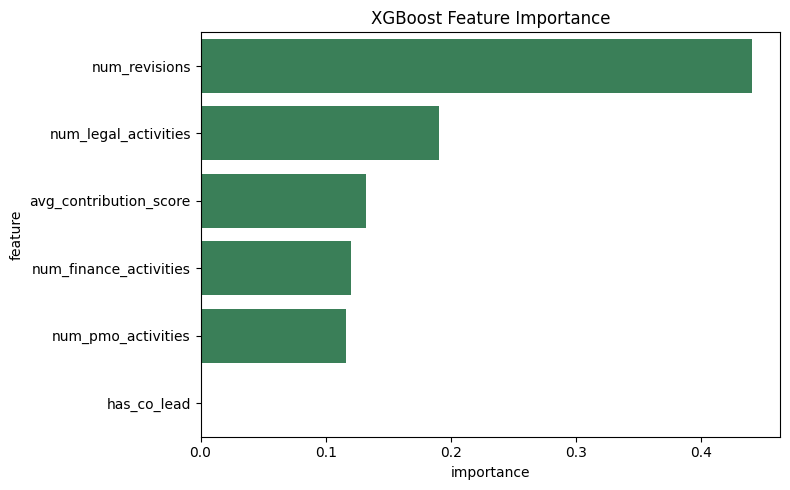

In [38]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_df, x='importance', y='feature', color='seagreen')
plt.title('XGBoost Feature Importance')
plt.tight_layout()
plt.show()

In [39]:
comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'XGBoost'],
    'ROC-AUC': [roc_auc_score(y_test, y_proba), roc_auc_score(y_test, y_proba_xgb)]
})
print(comparison)

                 Model   ROC-AUC
0  Logistic Regression  0.630075
1              XGBoost  0.608232


Since `num_revisions` is essentially the only real signal in this dataset, what if we used only `num_revisions` single-feature model as a final comparison point?

### Single-feature model (`num_revisions` only)

In [40]:
# Isolate just num_revisions to test if it alone captures most of the signal
X_train_single = X_train[['num_revisions']]
X_test_single = X_test[['num_revisions']]

# Scale (only one column now, but keep it consistent with the full model)
scaler_single = StandardScaler()
X_train_single_scaled = scaler_single.fit_transform(X_train_single)
X_test_single_scaled = scaler_single.transform(X_test_single)

log_reg_single = LogisticRegression(class_weight='balanced', random_state=42)
log_reg_single.fit(X_train_single_scaled, y_train)

y_proba_single = log_reg_single.predict_proba(X_test_single_scaled)[:, 1]
auc_single = roc_auc_score(y_test, y_proba_single)

print("Single-feature (num_revisions only) AUC:", auc_single)

Single-feature (num_revisions only) AUC: 0.6349103775098193


In [41]:
# Final 3-way comparison
comparison_final = pd.DataFrame({
    'Model': ['Logistic Regression (all features)', 'XGBoost (all features)', 'Logistic Regression (num_revisions only)'],
    'ROC-AUC': [
        roc_auc_score(y_test, y_proba),
        roc_auc_score(y_test, y_proba_xgb),
        auc_single
    ]
})
print(comparison_final)

                                      Model   ROC-AUC
0        Logistic Regression (all features)  0.630075
1                    XGBoost (all features)  0.608232
2  Logistic Regression (num_revisions only)  0.634910


## Key Findings - Delay Prediction

1. **`num_revisions` is the dominant predictor of project delay.** A logistic regression model using only this single feature achieves an AUC of 0.635 — slightly exceeding the AUC of a model using all 6 engineered features (0.630), and outperforming XGBoost's full-feature model (0.608).

2. **Additional engineered features (team structure, legal/PMO/finance activity counts) add negligible predictive value.** Despite testing a higher-capacity ensemble model (XGBoost) to capture potential non-linear interactions, performance did not improve over a simple logistic regression — indicating there are no meaningful hidden patterns for a more complex model to exploit in this dataset.

3. **Practical implication:** in this dataset, the number of plan revisions alone serves as a reasonably strong, simple heuristic for flagging at-risk project terms — a more complex model isn't justified given the available features.

4. **Limitation:** `num_revisions` is partly a *symptom* of delay rather than a clean early predictor, since projects that are already running late tend to accumulate more revisions (see Data Leakage Note above). This model should be understood as identifying *correlates* of delay rather than providing genuine early-warning capability. A future iteration restricting features to only what's known within the first revision or first 30 days of a term would be needed to test true predictive/early-warning value.

5. **Synthetic data caveat:** since the underlying delay values were generated as mock data, these findings reflect the structure built into the data-generation process rather than a real-world operational signal. The modeling pipeline — feature engineering, train/test evaluation, model comparison, and single-feature ablation — demonstrates the methodology that would be applied to genuine project data.